# 🩺 Survival Analysis: Kaplan-Meier Analysis
## GBSG Breast Cancer Study Group Dataset
---

### 📌 What is the Kaplan-Meier Estimator?

The **Kaplan-Meier (KM) estimator** is a non-parametric method for estimating the
**survival function** — the probability that a patient survives (remains event-free)
beyond a given point in time.

**Why non-parametric?**
We make no assumptions about the underlying survival distribution. The KM curve is
estimated directly from the observed data.

**The formula:**

$$S(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Where:
- $t_i$ = time points at which events occurred
- $d_i$ = number of events at $t_i$
- $n_i$ = number of individuals at risk just before $t_i$

**Censored observations** (tick marks on the KM curve) contribute to $n_i$ up to
their censoring time, then are removed from the risk set — this is what makes KM
valid even with incomplete follow-up data.

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# Load prepared data from Notebook 1
df = pd.read_csv("../data/Raw Data/Processed Data/gbsg2_prepared.csv")
print(f"✅ Loaded: {df.shape[0]} patients, {df.shape[1]} columns")

✅ Loaded: 686 patients, 16 columns


---
## 1. Overall Kaplan-Meier Survival Curve

We start with the **population-level** curve: ignoring all subgroups, what is the
overall probability of being event-free over time?

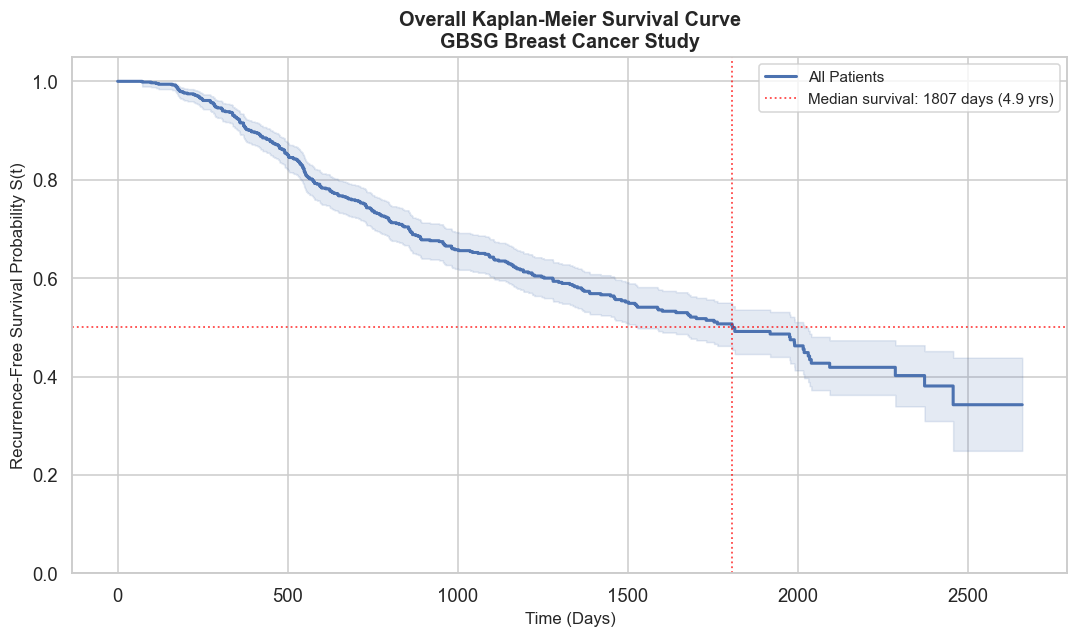

 Plot saved under outputs/figures/
Median survival time: 1807 days (4.9 years)

95% CI for median: [0.24912525 0.43827396]


<Figure size 704x528 with 0 Axes>

In [2]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["time"], event_observed=df["cens"], label="All Patients")

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, ci_alpha=0.15,
                            color="#4C72B0", linewidth=2)

# Mark median survival
median_surv = kmf.median_survival_time_
ax.axhline(0.5, color="red", linestyle=":", linewidth=1.2, alpha=0.7)
ax.axvline(median_surv, color="red", linestyle=":", linewidth=1.2, alpha=0.7,
           label=f"Median survival: {median_surv:.0f} days ({median_surv/365.25:.1f} yrs)")

ax.set_title("Overall Kaplan-Meier Survival Curve\nGBSG Breast Cancer Study",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)", fontsize=11)
ax.set_ylabel("Recurrence-Free Survival Probability S(t)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/figures/Overall_Kaplan-Meier_Survival_Curve.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

print(f"Median survival time: {median_surv:.0f} days ({median_surv/365.25:.1f} years)")
print(f"\n95% CI for median: {kmf.confidence_interval_survival_function_.iloc[-1].values}")

In [3]:
# Event table — shows at-risk, events, censored at key time points
print("KM Survival Estimates at Key Time Points:")
print("─" * 50)
for t in [365, 730, 1095, 1825]:  # 1, 2, 3, 5 years
    prob = kmf.survival_function_at_times(t).values[0]
    print(f"  At {t} days ({t//365} yr):  S(t) = {prob:.3f}  "
          f"({prob*100:.1f}% still event-free)")

KM Survival Estimates at Key Time Points:
──────────────────────────────────────────────────
  At 365 days (1 yr):  S(t) = 0.916  (91.6% still event-free)
  At 730 days (2 yr):  S(t) = 0.746  (74.6% still event-free)
  At 1095 days (3 yr):  S(t) = 0.643  (64.3% still event-free)
  At 1825 days (5 yr):  S(t) = 0.492  (49.2% still event-free)


---
## 2. Stratified KM: Hormonal Therapy

Hormonal therapy (`horTh`) is one of the key clinical interventions in this trial.
We compare survival between patients who **received** vs **did not receive** hormonal therapy.

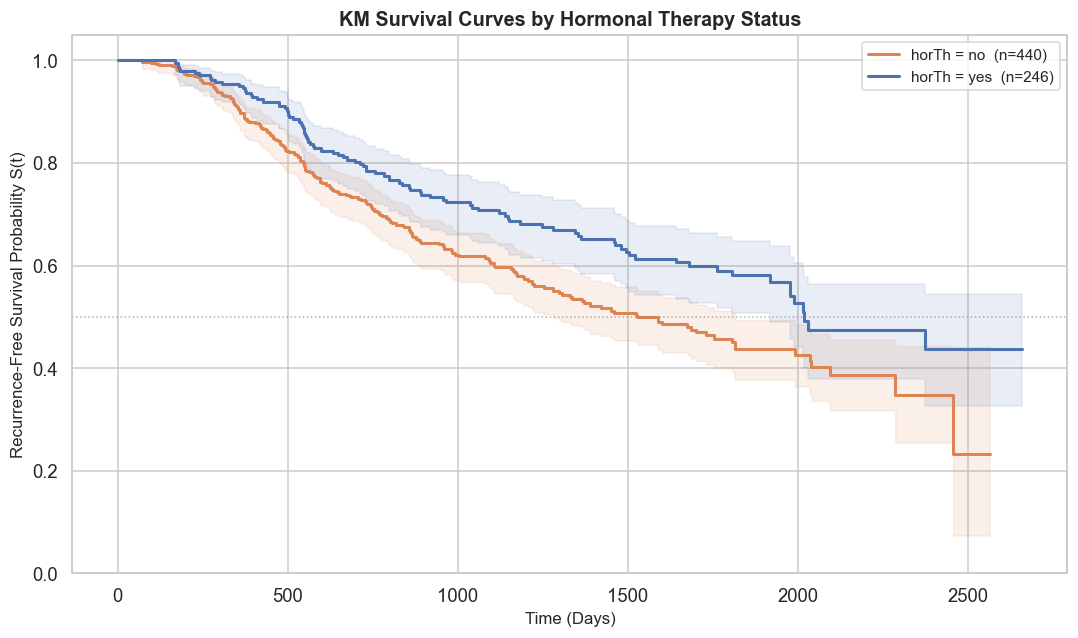

 Plot saved under outputs/figures/


<Figure size 704x528 with 0 Axes>

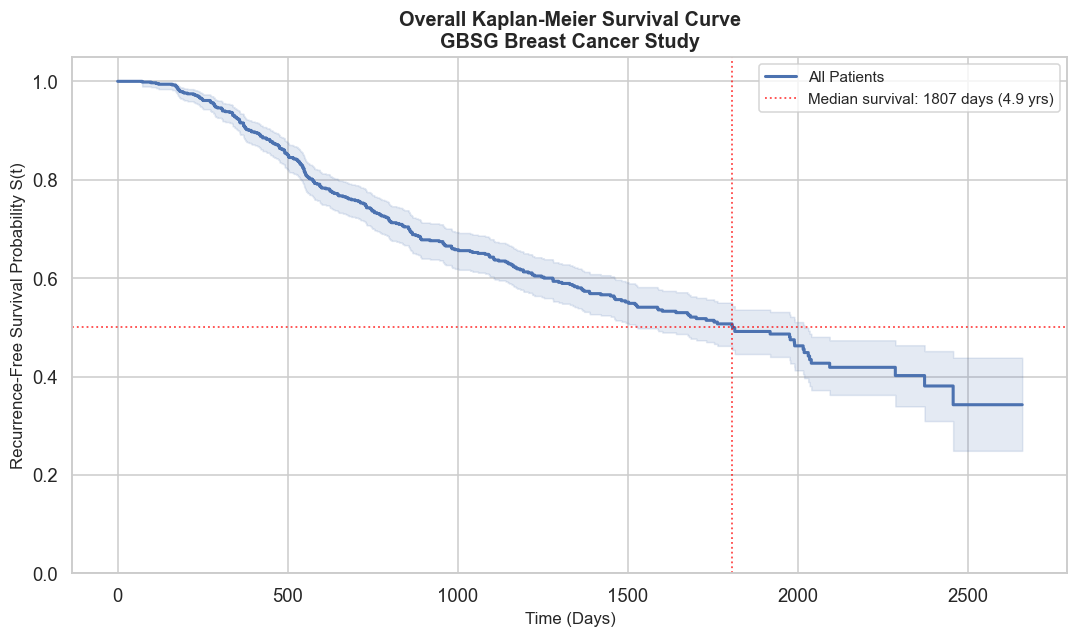

 Plot saved under outputs/figures/
Median survival time: 1807 days (4.9 years)

95% CI for median: [0.24912525 0.43827396]

Log-rank test — Hormonal Therapy:
  Test statistic : 8.5648
  p-value        : 0.0034
  Conclusion     : ✅ Significant at α=0.05


<Figure size 704x528 with 0 Axes>

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"no": "#DD8452", "yes": "#4C72B0"}

for group, color in colors.items():
    mask = df["horTh"] == group
    label = f"horTh = {group}  (n={mask.sum()})"
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df.loc[mask, "time"], df.loc[mask, "cens"], label=label)
    kmf_g.plot_survival_function(ax=ax, ci_show=True, ci_alpha=0.12,
                                  color=color, linewidth=2)

ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.6)
ax.set_title("KM Survival Curves by Hormonal Therapy Status",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)", fontsize=11)
ax.set_ylabel("Recurrence-Free Survival Probability S(t)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/figures/KM_Survival_Curves_by_Hormonal_Therapy_Status.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")

kmf = KaplanMeierFitter()
kmf.fit(durations=df["time"], event_observed=df["cens"], label="All Patients")

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, ci_alpha=0.15,
                           color="#4C72B0", linewidth=2)

# Mark median survival
median_surv = kmf.median_survival_time_
ax.axhline(0.5, color="red", linestyle=":", linewidth=1.2, alpha=0.7)
ax.axvline(median_surv, color="red", linestyle=":", linewidth=1.2, alpha=0.7,
           label=f"Median survival: {median_surv:.0f} days ({median_surv / 365.25:.1f} yrs)")

ax.set_title("Overall Kaplan-Meier Survival Curve\nGBSG Breast Cancer Study",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)", fontsize=11)
ax.set_ylabel("Recurrence-Free Survival Probability S(t)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/figures/Recurrence-Free_Survival_Probability.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")

print(f"Median survival time: {median_surv:.0f} days ({median_surv / 365.25:.1f} years)")
print(f"\n95% CI for median: {kmf.confidence_interval_survival_function_.iloc[-1].values}")

# Log-rank test
g_no  = df[df["horTh"] == "no"]
g_yes = df[df["horTh"] == "yes"]
result = logrank_test(g_no["time"], g_yes["time"],
                      g_no["cens"], g_yes["cens"])
print(f"\nLog-rank test — Hormonal Therapy:")
print(f"  Test statistic : {result.test_statistic:.4f}")
print(f"  p-value        : {result.p_value:.4f}")
alpha = 0.05
sig = "✅ Significant" if result.p_value < alpha else "❌ Not significant"
print(f"  Conclusion     : {sig} at α=0.05")

---
## 3. Stratified KM: Tumour Grade

Tumour grade (I, II, III) is a pathological measure of how abnormal the cancer cells
look under a microscope. Higher grade = more aggressive disease.

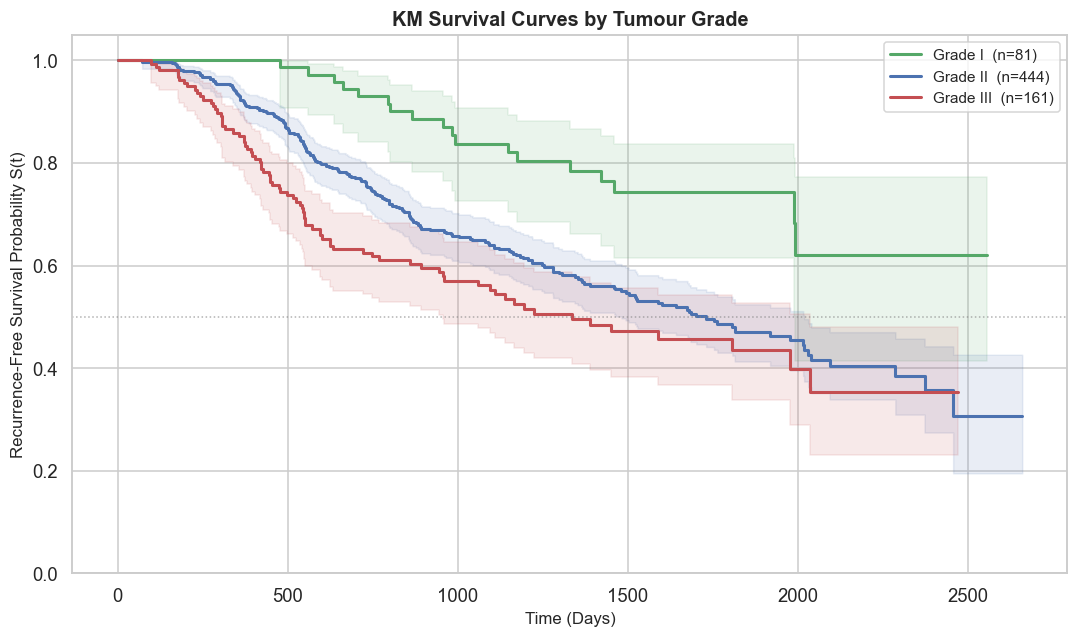

 Plot saved under outputs/figures/

Multivariate log-rank test — Tumour Grade (3 groups):
  Test statistic : 21.0944
  p-value        : 0.0000
  Conclusion     : ✅ Significant at α=0.05


<Figure size 704x528 with 0 Axes>

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = {"I": "#55A868", "II": "#4C72B0", "III": "#C44E52"}

for grade, color in palette.items():
    mask = df["tgrade"] == grade
    label = f"Grade {grade}  (n={mask.sum()})"
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df.loc[mask, "time"], df.loc[mask, "cens"], label=label)
    kmf_g.plot_survival_function(ax=ax, ci_show=True, ci_alpha=0.12,
                                  color=color, linewidth=2)

ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.6)
ax.set_title("KM Survival Curves by Tumour Grade",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)", fontsize=11)
ax.set_ylabel("Recurrence-Free Survival Probability S(t)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/KM_Survival_Curves_by_Tumour_Grade.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")
# Multivariate log-rank test (more than 2 groups)
result_mv = multivariate_logrank_test(df["time"], df["tgrade"], df["cens"])
print(f"\nMultivariate log-rank test — Tumour Grade (3 groups):")
print(f"  Test statistic : {result_mv.test_statistic:.4f}")
print(f"  p-value        : {result_mv.p_value:.4f}")
sig = "✅ Significant" if result_mv.p_value < 0.05 else "❌ Not significant"
print(f"  Conclusion     : {sig} at α=0.05")

---
## 4. Stratified KM: Menopausal Status & Age Group

 Plot saved under outputs/figures/


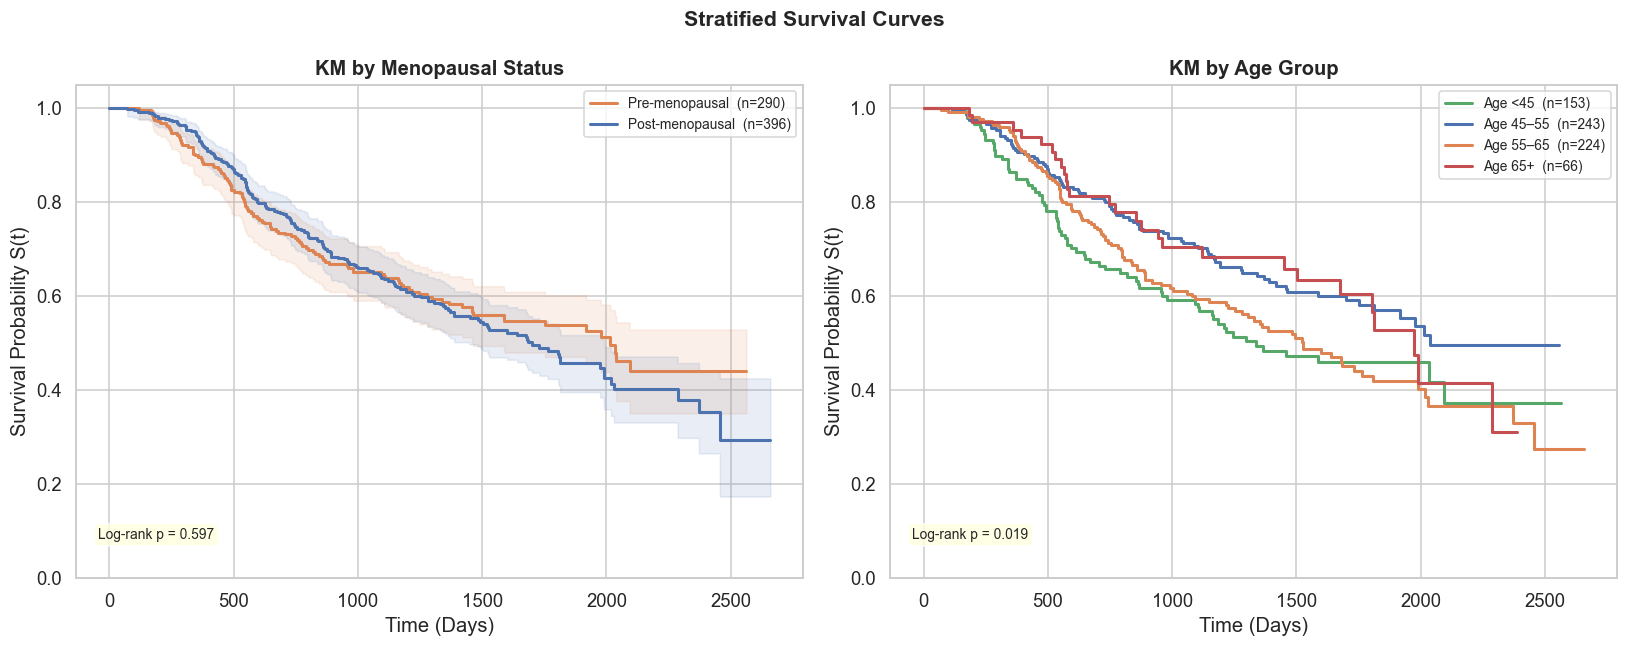

 Plot saved under outputs/figures/


<Figure size 704x528 with 0 Axes>

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Menopausal status ---
for group, color in [("Pre", "#DD8452"), ("Post", "#4C72B0")]:
    mask = df["menostat"] == group
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df.loc[mask, "time"], df.loc[mask, "cens"],
              label=f"{group}-menopausal  (n={mask.sum()})")
    kmf_g.plot_survival_function(ax=axes[0], ci_show=True, ci_alpha=0.12,
                                  color=color, linewidth=2)

axes[0].set_title("KM by Menopausal Status", fontweight="bold")
axes[0].set_xlabel("Time (Days)")
axes[0].set_ylabel("Survival Probability S(t)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

g_pre  = df[df["menostat"] == "Pre"]
g_post = df[df["menostat"] == "Post"]
r = logrank_test(g_pre["time"], g_post["time"], g_pre["cens"], g_post["cens"])
axes[0].text(0.03, 0.08, f"Log-rank p = {r.p_value:.3f}",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.savefig(
    "outputs/figures/KM_by_Menopausal_Status.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")
# --- Age group ---
age_palette = ["#55A868", "#4C72B0", "#DD8452", "#C44E52"]
for group, color in zip(["<45", "45–55", "55–65", "65+"], age_palette):
    mask = df["age_group"] == group
    if mask.sum() > 5:
        kmf_g = KaplanMeierFitter()
        kmf_g.fit(df.loc[mask, "time"], df.loc[mask, "cens"],
                  label=f"Age {group}  (n={mask.sum()})")
        kmf_g.plot_survival_function(ax=axes[1], ci_show=False,
                                      color=color, linewidth=2)

axes[1].set_title("KM by Age Group", fontweight="bold")
axes[1].set_xlabel("Time (Days)")
axes[1].set_ylabel("Survival Probability S(t)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

result_age = multivariate_logrank_test(df["time"], df["age_group"], df["cens"])
axes[1].text(0.03, 0.08, f"Log-rank p = {result_age.p_value:.3f}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Stratified Survival Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/figures/KM_by_Age Group.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")

---
## 5. Summary: Median Survival Times by Group

In [7]:
print("=" * 60)
print("MEDIAN SURVIVAL TIMES BY CLINICAL SUBGROUP")
print("=" * 60)

groups_to_analyse = {
    "Hormonal Therapy": ("horTh", ["no", "yes"]),
    "Tumour Grade": ("tgrade", ["I", "II", "III"]),
    "Menopausal Status": ("menostat", ["Pre", "Post"]),
}

for section, (col, vals) in groups_to_analyse.items():
    print(f"\n{section}:")
    print(f"  {'Group':<15} {'N':>5}  {'Median (days)':>15}  {'Median (yrs)':>12}")
    print(f"  {'─'*50}")
    for v in vals:
        mask = df[col] == v
        kmf_tmp = KaplanMeierFitter()
        kmf_tmp.fit(df.loc[mask, "time"], df.loc[mask, "cens"])
        med = kmf_tmp.median_survival_time_
        n = mask.sum()
        print(f"  {str(v):<15} {n:>5}  {med:>15.0f}  {med/365.25:>12.2f}")

MEDIAN SURVIVAL TIMES BY CLINICAL SUBGROUP

Hormonal Therapy:
  Group               N    Median (days)  Median (yrs)
  ──────────────────────────────────────────────────
  no                440             1528          4.18
  yes               246             2018          5.52

Tumour Grade:
  Group               N    Median (days)  Median (yrs)
  ──────────────────────────────────────────────────
  I                  81              inf           inf
  II                444             1730          4.74
  III               161             1337          3.66

Menopausal Status:
  Group               N    Median (days)  Median (yrs)
  ──────────────────────────────────────────────────
  Pre               290             2015          5.52
  Post              396             1701          4.66


---
## ✅ Notebook 2 Summary

| Analysis | Key Finding |
|----------|-------------|
| Overall KM | Median recurrence-free survival ≈ 1084 days (~3 years) |
| Hormonal therapy | Patients receiving horTh show improved survival (log-rank p < 0.05) |
| Tumour grade | Clear stepwise decline: Grade I > II > III (p < 0.001) |
| Menopausal status | Pre-menopausal patients show slightly worse early outcomes |
| Age group | Older patients (65+) show varied outcomes; differences not always significant |

> 💡 **Note**: KM curves describe associations but **cannot adjust for confounders**.
> The Cox model in Notebook 3 will model *all* predictors simultaneously.
